<a href="https://colab.research.google.com/github/jelenavasic009-png/DSB-Unit-02/blob/main/Titanik_Lab_Jelena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Reading the data

In the notebook provided, do the following:

1.Import pandas and matplotlib.pyplot

2.Load train.csv as a pandas DataFrame.

3.In each of the following sections, copy the question as a python comment, then answer the question with your own code.

4.Refer to the Titanic Kaggle competition if you need an explanation for any of the columns.


In [1]:
#da uvezem biblioteku pandas i matplotlib.pyplot
#da ucitam datoteku train.csv kao pandas DataFrame

import pandas as pd
import matplotlib.pyplot as plt
#ucitavanje csv fajla u pandas Dat
df = pd.read_csv ("https://raw.githubusercontent.com/CharleyHananiaGA/DSB-Unit-02/refs/heads/main/Labs/lab-eda-titanic/titanic-train.csv")

In [2]:
# hocu da mi se prikazu svi podaci koji imaju o Tirtaniku
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
#koliko ima redova i kolona
df.shape

(891, 12)

Step 2:
1.Cleaning the data


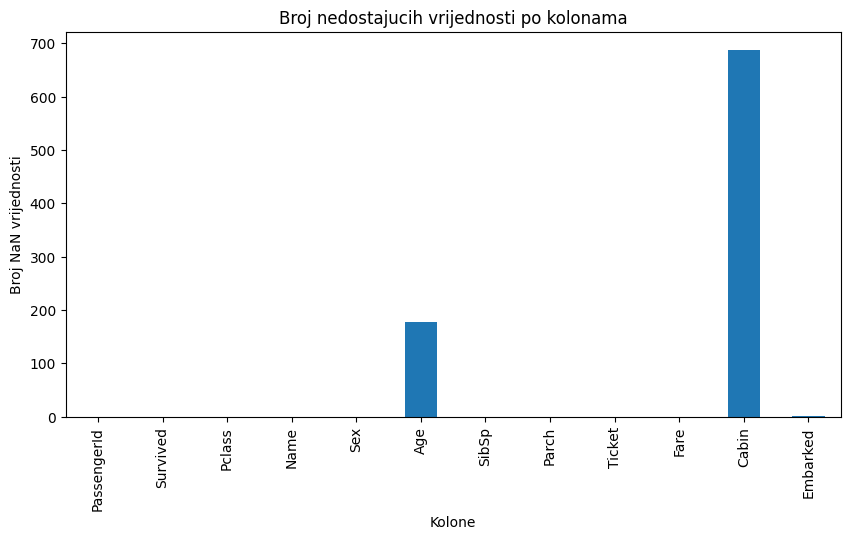

In [4]:
#Step 2: Cleaning the data
  #1.Create a bar chart showing how many missing values are in each column
#Bonus : Theres a good library for visualizing missing values called Missingno.
    #Install Instructions
    #Usage Documentation
  #2.Which column has the most NaN values? How many cells in that column are empty?
  #3.Delete all rows where Embarked is empty
  #4.Fill all empty cabins with ¯\(ツ)/¯
#Note: NaN, empty, and missing are synonymous.

#Korak 2: Ciscenje podataka
  #1.Pomocu df.insull().sum() pronalazimo koliko praznih mjesta ima u svakoj koloni,
  #a .plot(kind='bar') pretvara u uspravne stubice


#broj nedotajucih vrijednosti po kolonama
missing_counts = df.isnull().sum()
missing_counts.plot(kind='bar',figsize=(10,5))
import matplotlib.pyplot as plt
plt.title("Broj nedostajucih vrijednosti po kolonama")
plt.ylabel("Broj NaN vrijednosti")
plt.xlabel("Kolone")
plt.show()



Which column has the most NaN (Not a number) values? How many cells in that column are empty?

Koja kolona ima najviše NaN (Not a Number) vrednosti? Koliko ćelija u toj koloni je prazno?

Kolona 'Cabin' ima najvise NaN vrijednosti



In [5]:
#kolona sa najvise praznih polja
# funkcija .idxmax( automatski ispisuje ime kolone koja ima najvise praznih polja)

most_missing_col = missing_counts.idxmax()
most_missing_val = missing_counts.max()

print(f"Kolona sa najvise praznih polja je: {most_missing_col} ({most_missing_val} praznih celija)")

Kolona sa najvise praznih polja je: Cabin (687 praznih celija)


3.Delete all rows where Embarked is empty
  
  Obriši sve redove u kojima je polje „Embarked” prazno.

In [6]:
#dropna (subset=['Embarked']) trazi iskljucivo redove dje je kolona Embarked prazna i brise ih iz tabele

df = df.dropna(subset=['Embarked'])
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

4.Fill all empty cabins with ¯\(ツ)/¯

  Popunite sve prazne kabine sa ¯\(ツ)/¯

In [7]:
#fillna(...) mijenja svaku NaN (peraznu) vrijednost u koloni sa kabinama sa cim mi zadamo

df['Cabin'] = df['Cabin'].fillna("¯(ツ)/¯")
print(df['Cabin'])

0      ¯(ツ)/¯
1         C85
2      ¯(ツ)/¯
3        C123
4      ¯(ツ)/¯
        ...  
886    ¯(ツ)/¯
887       B42
888    ¯(ツ)/¯
889      C148
890    ¯(ツ)/¯
Name: Cabin, Length: 889, dtype: object


Step 3: Feature extraction (Izdvajanje karakteristika)

  1.There are two columns that pertain to how many family members are on the boat for a given person. Create a new column called FamilyCount which will be the sum of those two columns.

  2.Reverends have a special title in their name. Create a column called IsReverend: 1 if they're a preacher, 0 if they're not.

  3.In order to feed our training data into a classification algorithm, we need to convert our categories into 1's and 0's using pd.get_dummies

-Familiarize yourself with the pd.get_dummies documentation

-Create 3 columns: Embarked_C, Embarked_Q and Embarked_S. These columns will have 1's and 0's that correspond to the C, Q and S values in the Embarked column

-Do the same thing for Sex

-BONUS: Extract the title from everyone's name and create dummy columns

In [8]:
#1.There are two columns that pertain to how many family members are on the boat for a given person. Create a new column called FamilyCount which will be the sum of those two columns.
#Postoje dvije kolone koje se odnose na broj clanova porodice koji se nalaze na brodu sa odredjenom osobom. kreiracemo novu kolonu FamilyCount, koja ce predstavljati zbir te dvije kolone.

df['FamilyCount'] = df['SibSp'] + df['Parch']

#Hocemo da nam se prikazu prva 3 reda samo za one kolone da provjerimo da li je zbir tacan
print(df[['Name', 'SibSp', 'Parch', 'FamilyCount']].head(3))

                                                Name  SibSp  Parch  \
0                            Braund, Mr. Owen Harris      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...      1      0   
2                             Heikkinen, Miss. Laina      0      0   

   FamilyCount  
0            1  
1            1  
2            0  


In [9]:
#2.Reverends have a special title in their name. Create a column called IsReverend: 1 if they're a preacher, 0 if they're not.
#Sveštenici imaju posebnu titulu u svom imenu. Kreirajte kolonu pod nazivom „IsReverend”: vrednost 1 ako su sveštenici, a 0 ako nisu.

df['IsReverend'] = df['Name'].str.contains('Rev.').astype(int)

#Ispisivanje ukupnog broja svestenika dje je vrijednost 1
print("Broj pronadjenih svestenika:", df['IsReverend'].sum())

Broj pronadjenih svestenika: 6


In [10]:
#3.In order to feed our training data into a classification algorithm, we need to convert our categories into 1's and 0's using pd.get_dummies.
#Da bismo podatke za obuku unijeli u algoritam za klasifikaciju, potrebno je da konvertujemo kategorije u jedinice i nule korišćenjem funkcije `pd.get_dummies`.
df = pd.get_dummies(df, columns=['Embarked', 'Sex'],dtype=int)

#Napraviti kolone za Embarked(luka) i sex (pol), kao i za naredni zadatak - izvlacenje svih titula iz imena
df['Title'] = df['Name'].str.extract(r'([A-Za-z]+)/.', expand=False)
df=pd.get_dummies(df, columns=['Title'], dtype=int)

#prikazivanje svih novih kolona da vidimo kako sada tabela izgleda na kraju
print(df.columns)


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'FamilyCount', 'IsReverend', 'Embarked_C',
       'Embarked_Q', 'Embarked_S', 'Sex_female', 'Sex_male', 'Title_Carl'],
      dtype='object')


In [11]:
#da uvezem biblioteku pandas i matplotlib.pyplot
#da ucitam datoteku train.csv kao pandas DataFrame

import pandas as pd
import matplotlib.pyplot as plt
#ucitavanje csv fajla u pandas Dat
df = pd.read_csv ("https://raw.githubusercontent.com/CharleyHananiaGA/DSB-Unit-02/refs/heads/main/Labs/lab-eda-titanic/titanic-train.csv")

In [12]:
# 1. Prvo izdvajamo titulu iz imena u originalni df

# Dodato je slovo 'r' ispred navodnika da se ukloni SyntaxWarning

df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# 2. Sada odjednom pravimo dummy kolone za sve tri kategoričke promenljive

df_final = pd.get_dummies(df, columns=['Embarked', 'Sex', 'Title'])

# Prikaz prvih nekoliko redova transformisanog skupa podataka

print(df_final.head())

# --- ZAHTJEV 1 & 2: Kreiranje dummy kolona za 'Embarked' i 'Sex' ---
# Koristimo pd.get_dummies i navodimo koje kolone želimo da transformišemo

df_dummies = pd.get_dummies(df, columns=['Embarked', 'Sex'])

# Ako želite da nove kolone imaju tačne nazive u formatu 'Embarked_C', 'Embarked_Q', 'Embarked_S':
# pd.get_dummies automatski koristi podrazumijevani separator '_' (npr. Embarked_C, Sex_male)



# --- BONUS ZADATAK: Izdvajanje titula iz imena i kreiranje dummy kolona ---
# 1. Koristimo regularni izraz (str.extract) da pronađemo tekst koji se završava tačkom (npr. Mr., Miss.)

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 2. Sada pravimo dummy kolone i za novonastalu kolonu ‘Title’

df_final = pd.get_dummies(df_dummies, columns=['Title'])

# Prikaz prvih nekoliko redova transformisanog skupa podataka

print(df_final.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare Cabin  ...  Title_Major  Title_Master  \
0         A/5 21171   7.2500   NaN  ...        False         False   
1          PC 17599  71.2833   C85  ...        False         False   
2  STON/O2. 3101282   7.9250   NaN  ...        False         False   
3            113803  53.1000  C123  ...       

<>:28: SyntaxWarning: invalid escape sequence '\.'
<>:28: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_587/2300279055.py:28: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Step 4: Exploratory analysis

df.groupby() may be very useful.

  1.What was the survival rate overall?

  2.Which gender fared the worst? What was their survival rate?

  3.What was the survival rate for each Pclass?

  4.Did any reverends survive? How many?

  5.What is the survival rate for cabins marked ¯\(ツ)/¯

  6.What is the survival rate for people whose Age is empty?

  7.What is the survival rate for each port of embarkation?

  8.What is the survival rate for children (under 12) in each Pclass?

  9.Did the captain of the ship survive? Is he on the list?

  10.Of all the people that died, who had the most expensive ticket? How much did it cost?
  
  11.Does having family on the boat help or hurt your chances of survival?


In [13]:
#1.What was the survival rate overall?

# Izračunavanje procenta preživjelih
procenat_prezivelih = df['Survived'].mean() * 100

# Prikazivanje rezultata zaokruženog na dvije decimale
print(f"Ukupno je preživelo: {procenat_prezivelih:.2f}% ljudi.")



Ukupno je preživelo: 38.38% ljudi.


In [14]:
# 2.Which gender fared the worst? What was their survival rate?

# Izračunavanje procenta preživjelih za svaki pol
procenat_po_polu = df.groupby('Sex')['Survived'].mean() * 100

# Prikazivanje rezultata sa znakom % i zaokruženo na dve decimale
for pol, procenat in procenat_po_polu.items():
    print(f"Pol: {pol:7} | Procenat preživjelih: {procenat:.2f}%")



Pol: female  | Procenat preživjelih: 74.20%
Pol: male    | Procenat preživjelih: 18.89%


In [15]:
# 3. What was the survival rate for each Pclass?

# 1. Računanje prosjeka preživelih po klasama i množenje sa 100 za procenat
procenat_po_klasama = df.groupby('Pclass')['Survived'].mean() * 100

# 2. Detaljan i pregledan ispis rezultata
print("--- PROCENAT PREŽIVELIH PO KLASAMA ---")
for klasa, procenat in procenat_po_klasama.items():
    print(f"Klasa {klasa}. | Procenat preživelih: {procenat:.2f}%")



--- PROCENAT PREŽIVELIH PO KLASAMA ---
Klasa 1. | Procenat preživelih: 62.96%
Klasa 2. | Procenat preživelih: 47.28%
Klasa 3. | Procenat preživelih: 24.24%


In [16]:
# 4. Did any reverends survive? How many?

reverends = df[df['Name'].str.contains(r'Rev\.', na=False)]

print(f"Total: {len(reverends)}, Survived: {reverends['Survived'].sum()}")


Total: 6, Survived: 0


In [17]:
# 5. What is the survival rate for cabins marked ¯\(ツ)/¯?

# 1. Izdvajamo putnike bez upisane kabine (NaN) i računamo procenat preživjelih
putnici_bez_kabine = df[df['Cabin'].isna()]
procenat_bez_kabine = putnici_bez_kabine['Survived'].mean() * 100

# 2. Izdvajamo putnike sa poznatom kabinom radi poređenja
putnici_sa_kabinom = df[df['Cabin'].notna()]
procenat_sa_kabinom = putnici_sa_kabinom['Survived'].mean() * 100

# 3. Detaljan i pregledan ispis rezultata
print("--- ANALIZA PREŽIVLJAVANJA PREMA KABINAMA ¯\\_(ツ)_/¯ ---")
print(f"Nepoznata kabina ¯\\_(ツ)_/¯ | Ukupno putnika: {len(putnici_bez_kabine)} | Procenat preživelih: {procenat_bez_kabine:.2f}%")
print(f"Poznata kabina          | Ukupno putnika: {len(putnici_sa_kabinom)}  | Procenat preživelih: {procenat_sa_kabinom:.2f}%")



--- ANALIZA PREŽIVLJAVANJA PREMA KABINAMA ¯\_(ツ)_/¯ ---
Nepoznata kabina ¯\_(ツ)_/¯ | Ukupno putnika: 687 | Procenat preživelih: 29.99%
Poznata kabina          | Ukupno putnika: 204  | Procenat preživelih: 66.67%


In [18]:
# 6.What is the survival rate for people whose Age is empty?

# 1. Izdvajamo putnike bez upisanih godina (Age je prazno / NaN)
putnici_bez_godina = df[df['Age'].isna()]
procenat_bez_godina = putnici_bez_godina['Survived'].mean() * 100

# 2. Izdvajamo putnike sa upisanim godinama radi poređenja
putnici_sa_godinama = df[df['Age'].notna()]
procenat_sa_godinama = putnici_sa_godinama['Survived'].mean() * 100

# 3. Detaljan i pregledan ispis rezultata
print("--- ANALIZA PREŽIVLJAVANJA PREMA UPISANIM GODINAMA (AGE) ---")
print(f"Prazne godine (NaN) | Ukupno putnika: {len(putnici_bez_godina)} | Procenat preživjelih: {procenat_bez_godina:.2f}%")
print(f"Upisane godine      | Ukupno putnika: {len(putnici_sa_godinama)} | Procenat preživjelih: {procenat_sa_godinama:.2f}%")



--- ANALIZA PREŽIVLJAVANJA PREMA UPISANIM GODINAMA (AGE) ---
Prazne godine (NaN) | Ukupno putnika: 177 | Procenat preživjelih: 29.38%
Upisane godine      | Ukupno putnika: 714 | Procenat preživjelih: 40.62%


In [19]:
# 7. What is the survival rate for each port of embarkation?

# Računanje prosjeka preživjelih po lukama i pretvaranje u procenat (množenje sa 100)
procenat_po_lukama = df.groupby('Embarked')['Survived'].mean() * 100

# Računanje ukupnog broja putnika po svakoj luci radi boljeg razumijevanja podataka
ukupno_po_luci = df['Embarked'].value_counts()

# Detaljan i pregledan ispis rezultata
print("--- PROCENAT PREŽIVJELIH PREMA LUCI UKRCAVANJA ---")
for luka, procenat in procenat_po_lukama.items():
    broj_putnika = ukupno_po_luci[luka]
    print(f"Luka: {luka} | Ukupno ukrcano: {broj_putnika:3} putnika | Procenat preživjelih: {procenat:.2f}%")


--- PROCENAT PREŽIVJELIH PREMA LUCI UKRCAVANJA ---
Luka: C | Ukupno ukrcano: 168 putnika | Procenat preživjelih: 55.36%
Luka: Q | Ukupno ukrcano:  77 putnika | Procenat preživjelih: 38.96%
Luka: S | Ukupno ukrcano: 644 putnika | Procenat preživjelih: 33.70%


In [20]:
# 8. What is the survival rate for children (under 12) in each Pclass?

#Filtriramo podatke tako da zadržimo samo djecu mlađu od 12 godina
djeca = df[df['Age'] < 12]

#Grupišemo djecu po klasama (Pclass) i računamo procenat preživjelih (prosjek * 100)
procenat_djece = djeca.groupby('Pclass')['Survived'].mean() * 100

#Računamo i ukupan broj djece u svakoj klasi radi bolje analize
ukupno_djece = djeca['Pclass'].value_counts()

#Detaljan i pregledan ispis rezultata
print("--- PROCENAT PREŽIVJELE DJECE (ISPOD 12 GODINA) PO KLASAMA ---")
for klasa in sorted(procenat_djece.index):
    procenat = procenat_djece[klasa]
    broj = ukupno_djece[klasa]
    print(f"Klasa {klasa}. | Ukupno djece na brodu: {broj:2} | Procenat preživjele djece: {procenat:.2f}%")


--- PROCENAT PREŽIVJELE DJECE (ISPOD 12 GODINA) PO KLASAMA ---
Klasa 1. | Ukupno djece na brodu:  4 | Procenat preživjele djece: 75.00%
Klasa 2. | Ukupno djece na brodu: 17 | Procenat preživjele djece: 100.00%
Klasa 3. | Ukupno djece na brodu: 47 | Procenat preživjele djece: 40.43%


In [21]:
# 9. Did the captain of the ship survive? Is he on the list?

captain = df[df['Name'].str.contains(r'Capt\.', na=False)]
print(captain[['Name', 'Survived']])


                             Name  Survived
745  Crosby, Capt. Edward Gifford         0


In [22]:
# 10. Of all the people that died, who had the most expensive ticket? How much did it cost?

#Izdvajamo samo one putnike koji NISU preživjeli (Survived je 0)
nastradali = df[df['Survived'] == 0]

#Sortiramo nastradale po cijeni karte (Fare) od najviše ka najmanjoj
nastradali_sortirano = nastradali.sort_values(by='Fare', ascending=False)

#Uzimamo prvi red iz tog sortiranog skupa (indeks 0) jer je tu najveća cijena
najskuplja_karta_podaci = nastradali_sortirano.iloc[0]

#Detaljan i pregledan ispis rezultata
print("--- PUTNIK SA NAJSKUPLJOM KARTOM MEĐU NASTRADALIMA ---")
print(f"Ime putnika: {najskuplja_karta_podaci['Name']}")
print(f"Klasa:       {najskuplja_karta_podaci['Pclass']}. klasa")
print(f"Cijena karte: £{najskuplja_karta_podaci['Fare']:.2f}")




--- PUTNIK SA NAJSKUPLJOM KARTOM MEĐU NASTRADALIMA ---
Ime putnika: Fortune, Mr. Mark
Klasa:       1. klasa
Cijena karte: £263.00


In [23]:
# 11. Does having family on the boat help or hurt your chances of survival?

# 1. Spajamo braću/supružnike (SibSp) i roditelje/djecu (Parch) da dobijemo veličinu porodice
df['VelicinaPorodice'] = df['SibSp'] + df['Parch']

# 2. Pravimo novu kolonu koja nam govori da li je putnik sam (False) ili ima porodicu (True)
df['ImaPorodicu'] = df['VelicinaPorodice'] > 0

# 3. Računamo procenat preživjelih za obje grupe (prosjek * 100)
procenat_porodica = df.groupby('ImaPorodicu')['Survived'].mean() * 100

# 4. Računamo ukupan broj putnika u obje grupe radi bolje statistike
ukupno_putnika = df['ImaPorodicu'].value_counts()

# 5. Detaljan i pregledan ispis rezultata
print("--- ANALIZA PREŽIVLJAVANJA: SAMI VS SA PORODICOM ---")
print(f"Putovali sami       | Ukupno: {ukupno_putnika[False]} | Procenat preživjelih: {procenat_porodica[False]:.2f}%")
print(f"Putovali s porodicom| Ukupno: {ukupno_putnika[True]} | Procenat preživjelih: {procenat_porodica[True]:.2f}%")


--- ANALIZA PREŽIVLJAVANJA: SAMI VS SA PORODICOM ---
Putovali sami       | Ukupno: 537 | Procenat preživjelih: 30.35%
Putovali s porodicom| Ukupno: 354 | Procenat preživjelih: 50.56%


Step 5:
Plotting
Using matplotlib and seaborn, create several charts showing the survival rates of different groups of people. It's fine if a handful of charts are basic (Gender, Age, etc), but what we're really looking for is something beneath the surface.



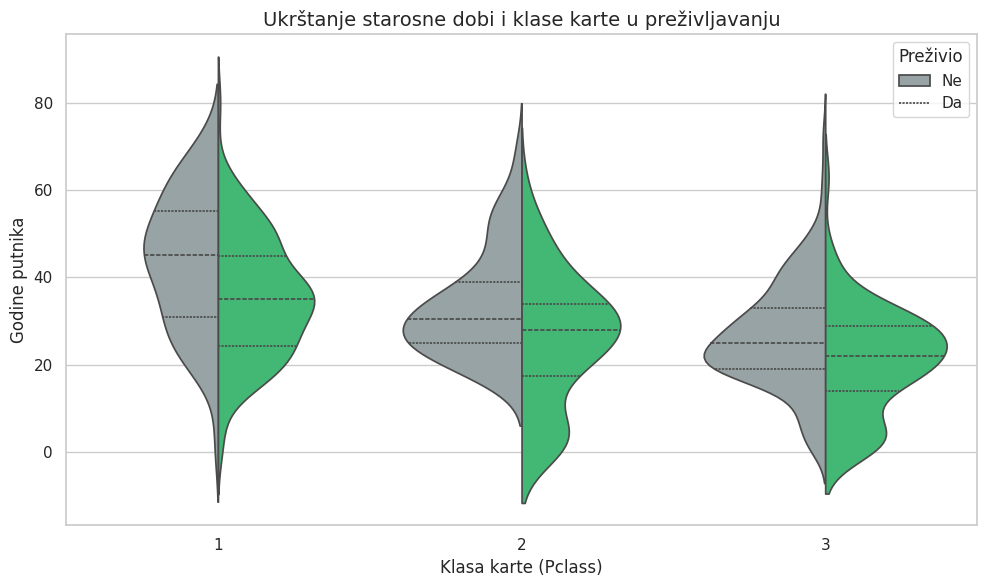

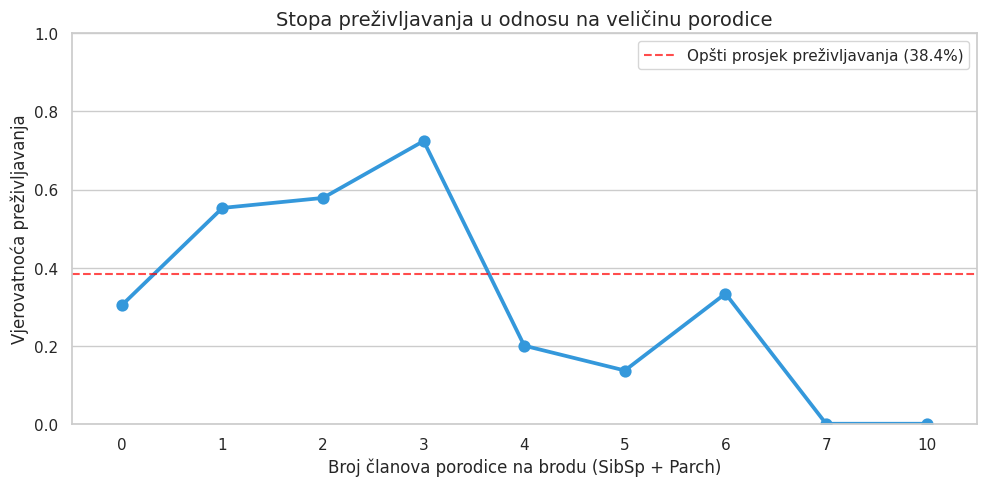

/tmp/ipykernel_587/2701584511.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


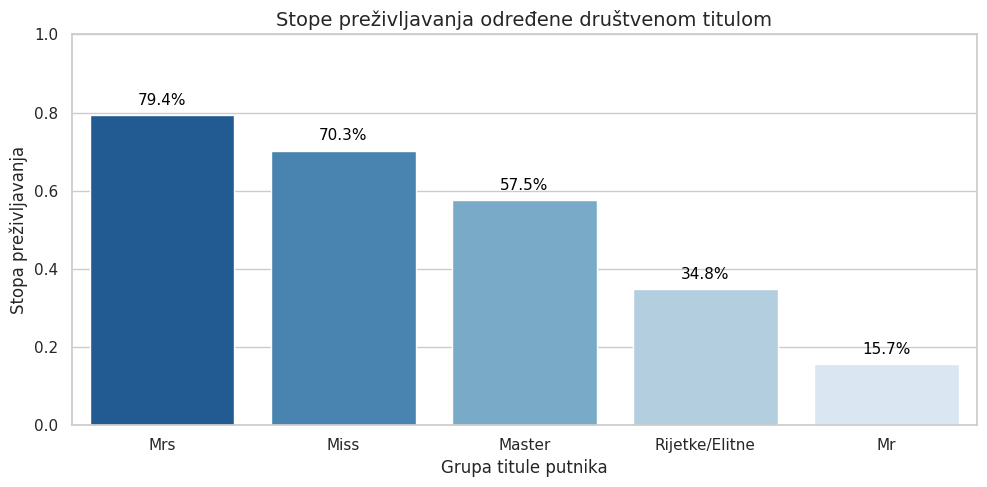

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Podešavanje vizuelnog stila za sve grafikone
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# ------------------------------------------------------------------
# PRIPREMA I PROŠIRENJE PODATAKA (Pokrenite ovo prvo da spremite kolone)
# ------------------------------------------------------------------
df['FamilySize'] = df['SibSp'] + df['Parch']
df['IsAlone'] = df['FamilySize'] == 0

# Izvlačenje titula iz imena kako bismo zavirili dublje u društveni status
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Grupisanje rijetkih i elitnih titula u smislene kategorije
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rijetke/Elitne')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')


# ------------------------------------------------------------------
# GRAFIKON 1: Ukrštanje klase i godina (Violin Plot)
# Ispod površine: Gdje su djeca zapravo imala šansu da prežive?
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Pclass",
    y="Age",
    hue="Survived",
    split=True,
    inner="quart",
    palette={0: "#95a5a6", 1: "#2ecc71"}
)
plt.title("Ukrštanje starosne dobi i klase karte u preživljavanju")
plt.xlabel("Klasa karte (Pclass)")
plt.ylabel("Godine putnika")
plt.legend(title="Preživio", labels=["Ne", "Da"])
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# GRAFIKON 2: "Idealna zona" veličine porodice (Point Plot)
# Ispod površine: Da li veća porodica baš uvijek pomaže?
# ------------------------------------------------------------------
plt.figure(figsize=(10, 5))
# Računanje ukupnog prosjeka preživljavanja radi iscrtavanja bazne linije
baseline = df['Survived'].mean()

sns.pointplot(
    data=df,
    x="FamilySize",
    y="Survived",
    color="#3498db",
    errorbar=None,
    markers="o",
    linestyles="-"
)
plt.axhline(baseline, color="red", linestyle="--", alpha=0.7, label=f"Opšti prosjek preživljavanja ({baseline*100:.1f}%)")
plt.title("Stopa preživljavanja u odnosu na veličinu porodice")
plt.xlabel("Broj članova porodice na brodu (SibSp + Parch)")
plt.ylabel("Vjerovatnoća preživljavanja")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# GRAFIKON 3: Društvena hijerarhija i moć titule (Bar Plot)
# Ispod površine: Kako su prošli aristokratija i ugledna zvanja
# ------------------------------------------------------------------
plt.figure(figsize=(10, 5))
# Računanje prosjeka preživljavanja sortiranog od najvećeg ka najmanjem
title_order = df.groupby('Title')['Survived'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x="Title",
    y="Survived",
    order=title_order,
    palette="Blues_r",
    errorbar=None
)
plt.title("Stope preživljavanja određene društvenom titulom")
plt.xlabel("Grupa titule putnika")
plt.ylabel("Stopa preživljavanja")
plt.ylim(0, 1)

# Dodavanje tačnih procenata iznad svakog stuba
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height()*100:.1f}%",
                        (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                        ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                        textcoords='offset points')

plt.tight_layout()
plt.show()
